<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic1.5-Parameter_Estimation/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Nonlinear Parameter Estimation

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic1.5-Parameter_Estimation_Problems.zip) <archives/Topic1.5-Parameter_Estimation_Problems.zip>` — the notebook and
`co2_isotherms_13x_multiT.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Nonlinear Parameter Estimation </1-numerical_methods/Topic1.5-Parameter_Estimation>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::



## Setup

This set returns to the dataset from
{doc}`the Numerical Optimization problems </problem_sets/Topic1.4-Numerical_Optimization_Problems>`:
CO₂ adsorption on **zeolite 13X**, the benchmark sorbent for post-combustion carbon
capture, from Yang et al., *Adsorption* **26**, 1305 (2020),
[doi:10.1007/s10450-020-00296-3](https://doi.org/10.1007/s10450-020-00296-3) via the
NIST/ARPA-E Adsorption Database.

Two things are different. First, you now have **six temperatures** rather than one — the
298 K rows are the identical points you fitted before. Second, the question has changed.
Last time you asked *where* the minimum is. This time you ask **how well the data pins it
down**, which turns out to be a much less comfortable question.

The model is the same Langmuir isotherm,

$$
q(P) \;=\; \frac{q_m\, b\, P}{1 + b\,P}
$$

with $q_m$ the saturation loading in mmol/g and $b$ the affinity constant in bar⁻¹.

In [ ]:
!pip install autograd

In [1]:
%matplotlib inline
import autograd.numpy as np
from autograd import hessian
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/co2_isotherms_13x_multiT.csv')
temperatures = sorted(int(T) for T in df['temperature [K]'].unique())
print(f"{len(df)} points across {len(temperatures)} temperatures: {temperatures}")

# The 298 K isotherm — the same points as the Topic 1.4 problem set.
iso298 = df[df['temperature [K]'] == 298]
P = iso298['pressure [bar]'].values
Q = iso298['loading [mmol/g]'].values
print(f"298 K: {len(P)} points, P = {P.min():.1e} to {P.max():.4f} bar")

196 points across 6 temperatures: [273, 283, 298, 323, 348, 373]
298 K: 35 points, P = 2.0e-05 to 0.9629 bar


:::{note}
The 273 K and 283 K isotherms each contain a few rows that share a pressure value. That
is a digitization artifact — the source figure has a logarithmic pressure axis, and at the
low end several distinct points round to the same number. The loadings still increase, and
least squares does not care whether two measurements share an abscissa, so there is
nothing to clean up. The 298 K isotherm has no repeats.
:::

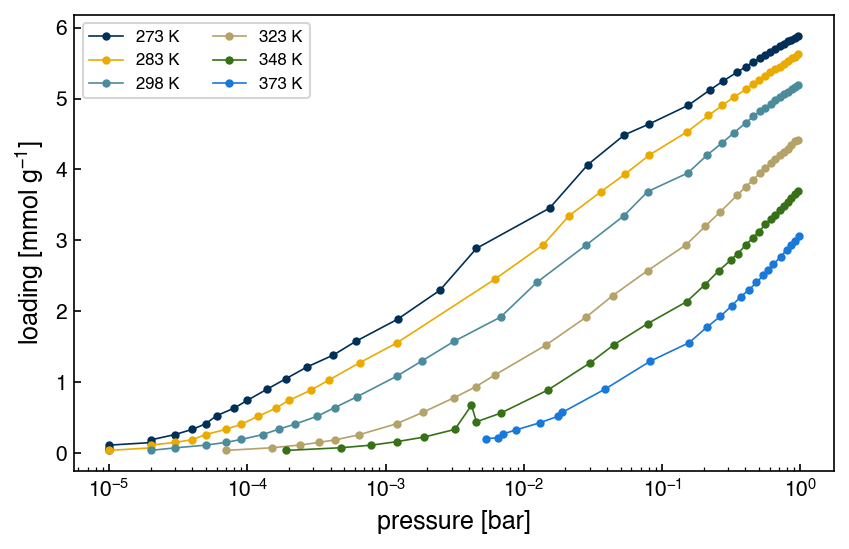

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
for T in temperatures:
    sub = df[df['temperature [K]'] == T]
    ax.semilogx(sub['pressure [bar]'], sub['loading [mmol/g]'], 'o-', ms=3, lw=0.8,
                label=f'{T} K')
ax.set_xlabel('pressure [bar]')
ax.set_ylabel('loading [mmol g$^{-1}$]')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout();

Run this once. It defines the `check` helper used after each Part A answer. It will
not run inside the book — use the downloaded notebook.

In [ ]:
# Run this once. It defines `check`, used after each Part A answer below.
import hashlib

_EXPECTED = {
    'q1': (5, ['a36660427635', 'da99809415dd', 'b9c7e22cd38f', 'e6b47068b093', '931c8f9b46a0', '586f0fbac076', 'd9e67ff28e72', '5910d5486ba4', 'f04806e52568']),
    'q2': (4, ['8418cabd9450', '056b2bc59a68', 'eecd9bfd3403', '9ef943d0480e', '3525504e2185']),
    'q3': (4, ['00b67256d7f5', 'faab3e07b021', '750c00b5e983', '5930366fae17', 'db9905e7ffcb', '0f348c413c60', 'a6e1cf32c1e8', '7d1c24d95176', 'c391045b7534', 'af526d09874f', 'a12b2ac4570d', 'f0adef132d61', 'e255737535bc']),
}

def check(qid, value):
    """Compare an answer against a stored digest. Practice only -- nothing is recorded."""
    places, digests = _EXPECTED[qid]
    if value is Ellipsis:
        print(f"{qid}: not answered yet")
        return
    got = hashlib.sha256(f"{float(value):.{places}f}".encode()).hexdigest()[:12]
    print(f"{qid}: {'correct' if got in digests else 'not the expected value'}")

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each, plus one ungraded bonus. Each graded question asks you to
assign a single number to a named variable. Run the check cell after each one; there is no
limit on attempts.

All three work on the **298 K isotherm only**, and all three build on the same fit. Set it
up once — the objective and the optimizer call are the same ones you wrote in
{doc}`the Numerical Optimization problems </problem_sets/Topic1.4-Numerical_Optimization_Problems>`.

In [3]:
def langmuir(lam, p):
    """Langmuir loading. lam = [q_m, b]."""
    return lam[0] * lam[1] * p / (1 + lam[1] * p)


def sse(lam):
    """Plain sum of squared errors on the 298 K isotherm."""
    return np.sum((langmuir(lam, P) - Q) ** 2)


result = minimize(sse, np.array([5.0, 65.0]), method='BFGS')
lam_opt = result.x
print(f"fitted q_m = {lam_opt[0]:.6f} mmol/g     fitted b = {lam_opt[1]:.4f} 1/bar")

fitted q_m = 4.861976 mmol/g     fitted b = 84.6257 1/bar


### A1. Estimate the noise (10 pts)

:::{exercise}
:label: pr-nm-lang-sigmahat

A sum of squares on its own says nothing about uncertainty. The chapter's first move is to
read the **noise level** off the residuals: if the measurements scatter around the model
with standard deviation $\sigma$, then

$$
\hat\sigma^2 \;=\; \frac{\mathrm{SSE}}{n - p}
$$

where $n$ is the number of measurements and $p$ the number of fitted parameters. The
$n - p$ rather than $n$ is what makes it unbiased — you spent $p$ degrees of freedom
fitting the model, so there are only $n - p$ left to measure scatter with.

Get the SSE at the optimum from the `OptimizeResult` above, and compute $\hat\sigma$ for
this fit. Count $n$ and $p$ yourself.

Assign it, in mmol/g, to `sigma_hat`.
:::

In [ ]:
# YOUR CODE HERE
sigma_hat = ...

In [ ]:
check("q1", sigma_hat)

### A2. Turn curvature into an error bar (10 pts)

::::{exercise}
:label: pr-nm-lang-se-qm

The width of the minimum is what tells you how well a parameter is determined. A sharply
curved minimum pins its parameter down; a flat one does not. Curvature is the **Hessian**,
the matrix of second derivatives, and `autograd` will give it to you exactly:

```python
from autograd import hessian
H = hessian(sse)(lam_opt)
```

For a sum-of-squares objective the covariance matrix of the fitted parameters is

$$
\bar{\bar{C}} \;=\; 2\,\hat\sigma^2 \,\bar{\bar{H}}^{-1}
$$

The factor of 2 comes from differentiating a sum of squares twice. The standard error of
each parameter is the square root of the corresponding diagonal entry.

Compute the standard error of the saturation loading $q_m$, in mmol/g, and assign it to
`se_q_m`.

:::{warning}
Do **not** use `result.hess_inv` from `minimize`. BFGS builds that matrix as a by-product
of its search and it is not accurate enough to quote as an uncertainty — the chapter warns
about this explicitly. Use `autograd`'s exact Hessian.
:::
::::

In [ ]:
# YOUR CODE HERE
se_q_m = ...

In [ ]:
check("q2", se_q_m)

### Bonus. Where does the factor of 2 come from? (0 pts, ungraded)

:::{exercise}
:label: pr-nm-lang-derive-cov

A2 handed you $\bar{\bar{C}} = 2\hat\sigma^2\bar{\bar{H}}^{-1}$ without justification. Derive
it. This is **pen and paper** — no code, no autograder, no points. It is here because the
factor of 2 is the one part of the formula that looks arbitrary, and it is not.

Work in this order:

1. Write the likelihood of the data under the chapter's noise model,
   $q_i = q(P_i;\vec\lambda) + \epsilon_i$ with
   $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$ independent. Take its logarithm and show that
   $-\ln L = \mathrm{SSE}(\vec\lambda)/(2\sigma^2) + \text{const}$, where the constant does
   not depend on $\vec\lambda$.
2. Expand $\mathrm{SSE}$ to second order about the optimum $\hat{\vec\lambda}$. The gradient
   vanishes there, so only the quadratic term survives:
   $\mathrm{SSE} \approx \mathrm{SSE}(\hat{\vec\lambda}) + \tfrac12 \Delta\vec\lambda^T
   \bar{\bar{H}} \Delta\vec\lambda$ with $\bar{\bar{H}}$ the Hessian of **SSE**.
3. Substitute into step 1 and compare the result with the standard form of a multivariate
   Gaussian in $\Delta\vec\lambda$, whose exponent is
   $-\tfrac12 \Delta\vec\lambda^T \bar{\bar{C}}^{-1} \Delta\vec\lambda$. Read off
   $\bar{\bar{C}}$.

Say in one line where the 2 came from.
:::


### A3. Are the two parameters independent? (10 pts)

:::{exercise}
:label: pr-nm-lang-corr

The off-diagonal entries of $\bar{\bar{C}}$ say whether the two parameters are determined
*separately*. Normalize them into a correlation coefficient:

$$
\mathrm{corr}(\lambda_i, \lambda_j)
\;=\; \frac{C_{ij}}{\sqrt{C_{ii}}\,\sqrt{C_{jj}}}
$$

which is $\pm 1$ when the two parameters are perfectly redundant and 0 when they are
independent.

Compute the correlation between $q_m$ and $b$ and assign it to `corr_qm_b`. **Keep the
sign** — it means something.
:::

In [ ]:
# YOUR CODE HERE
corr_qm_b = ...

In [ ]:
check("q3", corr_qm_b)

---

## Part B — Visualization (35 pts)

Your A2 standard errors said $q_m$ is determined to about 2% and $b$ to about 22%, from one
fit of one model to one isotherm. This part asks whether those error bars can be trusted, by
changing three things — the model, the pressure range, and the temperature — and watching
what the uncertainties do.

A second isotherm model, which you will need throughout. The **Tóth** equation relaxes
Langmuir's assumption that every adsorption site is identical:

$$
q(P) \;=\; \frac{q_m\, b\, P}{\left[1 + (bP)^{t}\right]^{1/t}}
$$

The exponent $t$ describes how spread out the site energies are, and $t = 1$ recovers
Langmuir exactly. Fit it in **log parameters** — all three are positive, and you saw in
{doc}`the Numerical Optimization problems </problem_sets/Topic1.4-Numerical_Optimization_Problems>`
what a badly scaled parameter vector does to an optimizer.

::::{exercise}
:label: pr-nm-lang-two-models

**1. Two models, one isotherm.** Fit Langmuir and Tóth to the 298 K data. For each, report
the SSE, $\hat\sigma$, every parameter with its standard error, and `np.linalg.cond` of the
Hessian. Plot both fitted curves over the data on a **logarithmic pressure axis**, with a
residual panel ($q - \hat q$) beneath on shared axes.

**2. Where the models cannot be told apart.** Refit Langmuir using **only the points below
$2\times10^{-3}$ bar**. Say how many points that leaves, and check the largest value of $bP$
among them, so you can say whether the isotherm is still in its linear (Henry) regime there.

Then plot three curves — full-data Langmuir, Tóth, and this low-pressure Langmuir — zoomed
into that low-pressure region on **linear** axes, with the low-pressure points shown. Report
$q_m$ and its standard error for both Langmuir fits.

**3. Confidence regions.** For the two Langmuir fits from task 2, draw both **95% confidence
ellipses** in the $(q_m, b)$ plane on one set of axes, built from the eigen-decomposition of
each $2\times2$ covariance matrix: the eigenvectors give the axis directions and the
semi-axis lengths are $\sqrt{\chi^2_{0.95,\,2}\lambda_i}$, with `chi2.ppf(0.95, df=2)` from
`scipy.stats`. Mark both best-fit points.

Report the two condition numbers, and the disagreement between the two $q_m$ estimates
**expressed in units of the low-pressure fit's own standard error**.

Then, **in one or two sentences**: that disagreement is enormous while the low-pressure
standard error is *smaller* than the full-data one. Say which of the quantities you computed
did warn you that the low-pressure fit was untrustworthy.

**4. One temperature is not enough.** Take the full-data 298 K Langmuir fit — parameters
fixed, nothing refitted — and plot it against **all six** isotherms on one logarithmic
pressure axis. For each temperature, report the SSE of that single fixed curve against the
SSE of a Langmuir fit to that temperature alone.

Label your axes with units.
::::

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots()

---

## Part C — Open Ended (35 pts)

One question, and it is the question the whole set has been building toward.

Part B showed that a fit to a single isotherm cannot describe the material. But the six
isotherms are not six unrelated experiments: $q_m$ counts adsorption sites, and the number of
sites does not change when you warm the gas up, while $b$ measures how strongly CO₂ binds and
thermodynamics says exactly how that should vary with temperature:

$$
b(T) \;=\; b_0 \exp\!\left(-\frac{\Delta H_{\mathrm{ads}}}{R T}\right)
$$

This is the **van't Hoff** relation. $\Delta H_{\mathrm{ads}}$ is the enthalpy of adsorption
— negative, because adsorption releases heat — and it is the single most useful number in
this dataset: it sets how much energy a capture process must spend to get the CO₂ back out
again. For zeolite 13X the literature value is roughly **−35 to −50 kJ/mol**.

Use $R = 8.314462618$ J mol⁻¹ K⁻¹. Watch the units: if you carry
$\Delta H_{\mathrm{ads}}$ in kJ/mol you need a factor of 1000 inside the exponential. Fit
$\ln b_0$ rather than $b_0$, which is many orders of magnitude smaller than $q_m$.

::::{exercise}
:label: pr-nm-lang-report-enthalpy

**Fit both models — Langmuir and Tóth — to all six isotherms at once**, coupling them
through the van't Hoff relation above: one shared $q_m$, one shared $b_0$, one shared
$\Delta H_{\mathrm{ads}}$ (and for Tóth, one shared $t$). Then **compare the parameters and
their uncertainties between the two models, and report the adsorption enthalpy you would
defend for this dataset.**

What you must hand in:

1. Both coupled fits: every parameter with a standard error, the SSE, and cond$(H)$.
2. At least one figure that supports your conclusion.
3. **Your reported $\Delta H_{\mathrm{ads}}$, with a 95% interval**, and one or two sentences
   saying why you chose it over the alternative.

How you argue is up to you. Evidence you already know how to produce, and may use as much or
as little of as you find useful:

- the per-temperature fits from Part B, and what the coupled fit does to their scatter;
- `scipy.optimize.curve_fit` on the same coupled model, whose `pcov` gives a second opinion
  on the uncertainties;
- the **linearized** route — fit Langmuir at each temperature separately, then regress
  $\ln b$ against $1/T$ by ordinary least squares and read
  $\Delta H_{\mathrm{ads}} = -R \times \text{slope}$;
- the condition numbers, the correlation matrix, and the residuals.

:::{admonition} A hint about starting guesses
:class: tip

The coupled fits are three- and four-parameter problems and they do care where you start.
The linearized route above is a cheap way to get a starting value for $\ln b_0$ and
$\Delta H_{\mathrm{ads}}$, and Part B's per-temperature fits give you one for $q_m$ (and
$t$). As in Part B, do not trust `result.success` on the Tóth fit — check the SSE from more
than one starting point instead.
:::
::::

In [ ]:
# YOUR CODE HERE